In [49]:
import matplotlib.pyplot as plt
import numpy as np
from reservoirpy.observables import nrmse, rsquare
from reservoirpy.nodes import Ridge, NVAR
from pandas import read_csv
%matplotlib inline

In [50]:
data_time = read_csv('../Dataset/noise_Lorenz_data.csv', usecols=[0])
time = data_time.values
time = time.astype('float32')

data_noise_Lorenz = read_csv('../Dataset/noise_Lorenz_data.csv', usecols=[1, 2, 3])
data_noise_Lorenz = data_noise_Lorenz.values
data_noise_Lorenz = data_noise_Lorenz.astype('float32')

X = data_noise_Lorenz
total_steps = len(X)
warm_steps = round(0.30*total_steps)
train_steps = round(0.50*total_steps)
test_steps = round(0.20*total_steps)

In [51]:
nvar = NVAR(delay=2, order=2, strides=1)
readout = Ridge(3, ridge=2.5e-6)
model = nvar >> readout

pred_steps = 1
Xi  = X[:train_steps+warm_steps-pred_steps]
dXi = X[pred_steps:train_steps+warm_steps] - X[:train_steps+warm_steps-pred_steps]

model = model.fit(Xi, dXi, warmup=warm_steps)

Running Model-7: 3999it [00:00, 13739.53it/s]?, ?it/s]
Running Model-7: 100%|██████████| 1/1 [00:00<00:00,  3.40it/s]


Fitting node Ridge-7...


In [52]:
nvar.run(X[warm_steps+train_steps-2:warm_steps+train_steps])
u = X[warm_steps+train_steps]
res = np.zeros((test_steps, readout.output_dim))
for i in range(test_steps):
    u = u + model(u)
    res[i, :] = u

Running NVAR-7: 100%|██████████| 2/2 [00:00<00:00, 1976.11it/s]


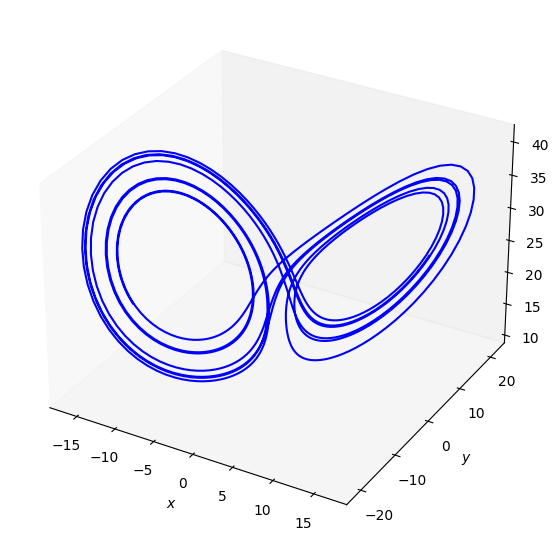

In [55]:
N = test_steps
Y = X[warm_steps+train_steps:]

fig = plt.figure(figsize=(15, 10))
ax  = fig.add_subplot(121, projection='3d')
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.grid(False)
ax.plot(res[:, 0], res[:, 1], res[:, 2], color='b')

# ax2  = fig.add_subplot(122, projection='3d')
# ax2.plot(Y[:, 0], Y[:, 1], Y[:, 2], color='r')
# ax2.grid(False)

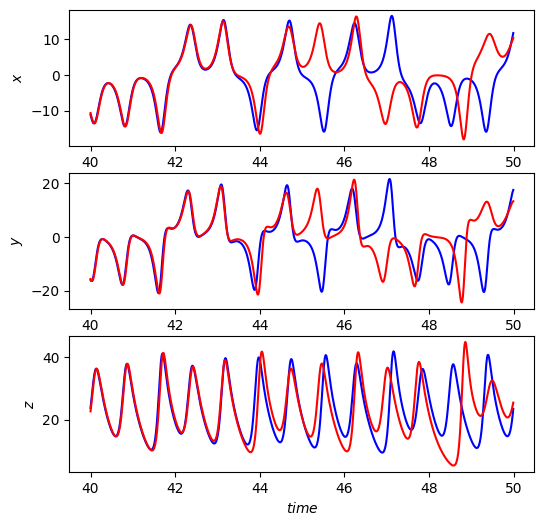

In [58]:
data_Lorenz = read_csv('../Dataset/Lorenz_data.csv', usecols=[1, 2, 3])
data_Lorenz = data_Lorenz.values
data_Lorenz = data_Lorenz.astype('float32')
# Y = data_Lorenz[warm_steps+train_steps:]

T = time[warm_steps+train_steps:]

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(311)
ax.set_ylabel("$x$")
ax.grid(False)
ax.plot(T, res[:, 0], color='b')
ax.plot(T, Y[:, 0], color='r')

ax2 = fig.add_subplot(312)
ax2.set_ylabel("$y$")
ax2.grid(False)
ax2.plot(T, res[:, 1], color='b')
ax2.plot(T, Y[:, 1], color='r')

ax3 = fig.add_subplot(313)
ax3.set_xlabel("$time$")
ax3.set_ylabel("$z$")
ax3.grid(False)
ax3.plot(T, res[:, 2], color='b')
ax3.plot(T, Y[:, 2], color='r')
